# Track jitter / spike / drop-out examples

Produces the three figures used in §3.3 of `main4.tex`:

1. `jitter_3d_raw_track.png` — 3D scatter of a single raw flight track,
   red crosses on spike frames, red dot at the camera origin.
2. `jitter_velocity_profile.png` — frame-to-frame velocity vs time with
   the 7 m/s biological ceiling overlaid.
3. `jitter_before_after_preprocessing.png` — top-down trajectory and
   velocity profile before vs after spike-heal + 5-frame rolling-mean
   smoothing.

**How to use:**

1. Open the config cell below.
2. Either set `TARGET_UID = <some_uid>` directly (e.g. `2013583`) to
   inspect a specific track, **or** leave `TARGET_UID = None` and the
   notebook will auto-pick the worst track in the selected folder.
3. `FIG_OUT_DIR` controls where the PNGs are written. Default is the
   Overleaf `Images/` folder so a save here updates §3.3 directly.


In [15]:
# ── Configuration ──
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # registers the 3d projection

# Preprocessing thresholds — match multi_day_pipeline_v3.ipynb
FPS               = 60.0
MAX_BIO_VELOCITY  = 7.0          # m/s — biological ceiling
SMOOTH_WINDOW     = 5            # centred rolling-mean window
MIN_TRACK_FRAMES  = 10

# Where to look for raw flight tracks
DATA_BASE = Path("../../data/flight_data")

# === EDIT THESE TWO LINES ===
FOLDER     = "2026-05-02_system_900"   # day-system folder name
TARGET_UID = 2013583                   # set to None to auto-pick the worst track
# ============================

# Where to save the figures (None = display only, don't save)
FIG_OUT_DIR = Path("../../../Overleaf/Images")
SAVE_FIGS   = True

# Camera origin in track coordinates (PATS-C convention: camera at (0,0,0))
CAMERA_XYZ = np.array([0.0, 0.0, 0.0])

print(f"Folder       : {FOLDER}")
print(f"Target UID   : {TARGET_UID if TARGET_UID is not None else 'auto-pick'}")
print(f"Save figures : {SAVE_FIGS} -> {FIG_OUT_DIR.resolve() if SAVE_FIGS else '(display only)'}")


Folder       : 2026-05-02_system_900
Target UID   : 2013583
Save figures : True -> /Users/jaspe/Projects/Claude/Overleaf/Images


## Load the selected day-system folder

In [16]:
# ── Load tracks for the selected day-system ──
csv = DATA_BASE / FOLDER / "flight_tracks.csv"
if not csv.exists():
    raise FileNotFoundError(f"flight_tracks.csv not found at {csv.resolve()}")

ft = pd.read_csv(csv, usecols=["detection_uid", "elapsed", "pos_valid_insect",
                                "posX_insect", "posY_insect", "posZ_insect"])
ft = ft[ft["pos_valid_insect"] == 1]
print(f"Loaded {len(ft):,} valid frames across {ft['detection_uid'].nunique()} tracks "
      f"from {FOLDER}")


Loaded 265,573 valid frames across 1266 tracks from 2026-05-02_system_900


## Pick the track to analyse

If `TARGET_UID` is set, just use it. Otherwise compute the maximum
frame-to-frame velocity per track and pick the worst one as a fallback.

In [17]:
# ── Resolve the UID to analyse ──
def max_frame_velocity(group):
    g = group.sort_values("elapsed")
    coords = g[["posX_insect", "posY_insect", "posZ_insect"]].values
    if len(coords) < 5:
        return np.nan
    dt = np.diff(g["elapsed"].values)
    if np.any(dt <= 0):
        return np.nan
    return float(np.nanmax(np.linalg.norm(np.diff(coords, axis=0), axis=1) / dt))

if TARGET_UID is None:
    per_track_max_v = (ft.groupby("detection_uid")
                         .apply(max_frame_velocity, include_groups=False)
                         .dropna()
                         .sort_values(ascending=False))
    print("Top 10 tracks by maximum frame-to-frame velocity (m/s):")
    print(per_track_max_v.head(10).round(1).to_string())
    UID = int(per_track_max_v.index[0])
    print(f"\nAuto-picked UID {UID}  (max frame-to-frame speed "
          f"{per_track_max_v.iloc[0]:.1f} m/s).")
else:
    UID = int(TARGET_UID)
    if UID not in ft["detection_uid"].unique():
        raise ValueError(f"UID {UID} not present in {FOLDER}. "
                         f"Available UIDs: {sorted(ft['detection_uid'].unique())[:20]} ...")
    print(f"Using TARGET_UID = {UID}.")

# Extract the track
trk = (ft[ft["detection_uid"] == UID]
         .sort_values("elapsed").reset_index(drop=True))
x, y, z = trk["posX_insect"].values, trk["posY_insect"].values, trk["posZ_insect"].values
t  = trk["elapsed"].values - trk["elapsed"].iloc[0]
dt = np.diff(t)

speeds  = np.linalg.norm(np.diff(np.c_[x, y, z], axis=0), axis=1) / dt
mid_t   = (t[:-1] + t[1:]) / 2
spike_mask = np.concatenate([[False], speeds > MAX_BIO_VELOCITY])
n_spikes   = int(spike_mask.sum())

print(f"Track {UID}:")
print(f"  frames                : {len(trk)}")
print(f"  duration              : {t[-1]:.2f} s")
print(f"  bbox  dx={x.max()-x.min():.2f} m  dy={y.max()-y.min():.2f} m  dz={z.max()-z.min():.2f} m")
print(f"  peak frame-to-frame v : {speeds.max():.2f} m/s")
print(f"  spike frames (>7 m/s) : {n_spikes}")


Using TARGET_UID = 2013583.
Track 2013583:
  frames                : 202
  duration              : 2.24 s
  bbox  dx=0.48 m  dy=0.62 m  dz=1.08 m
  peak frame-to-frame v : 15.02 m/s
  spike frames (>7 m/s) : 3


## Figure 1 — Raw 3D trajectory with camera origin

The track is coloured by time since track start. Red crosses mark spike
frames. The red dot at the origin marks the camera position (PATS-C
convention: camera at (0, 0, 0); positive depth increases away from the
camera in -z).

saved /Users/jaspe/Projects/Claude/Overleaf/Images/jitter_3d_raw_track.png


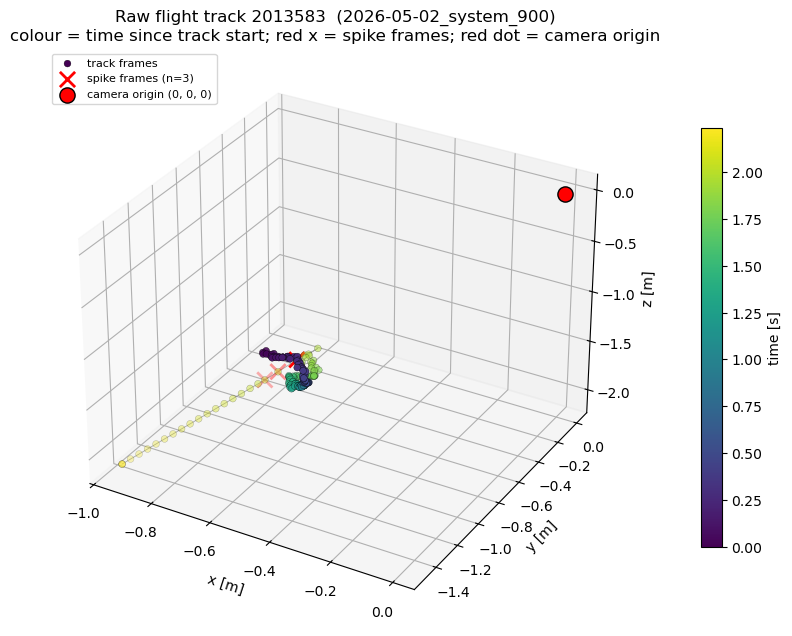

In [21]:
# ── Figure 1: 3D raw trajectory + spike markers + camera dot ──
fig = plt.figure(figsize=(8, 6.5))
ax  = fig.add_subplot(111, projection="3d")

# faint connecting line + per-frame scatter coloured by time
ax.plot(x, y, z, "-", color="#666", linewidth=0.6, alpha=0.55)
sc = ax.scatter(x, y, z, c=t, cmap="viridis", s=24,
                edgecolor="black", linewidth=0.25, label="track frames")

# spike frames highlighted
if n_spikes:
    ax.scatter(x[spike_mask], y[spike_mask], z[spike_mask],
               c="red", s=120, marker="x", linewidth=2,
               label=f"spike frames (n={n_spikes})")

# camera position at the origin
ax.scatter(*CAMERA_XYZ, c="red", s=120, marker="o",
           edgecolor="black", linewidth=1, zorder=10,
           label="camera origin (0, 0, 0)")

ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.set_title(f"Raw flight track {UID}  ({FOLDER})\n"
             f"colour = time since track start; red x = spike frames; "
             f"red dot = camera origin")
ax.legend(loc="upper left", fontsize=8)
fig.colorbar(sc, ax=ax, label="time [s]", shrink=0.7, pad=0.1)
plt.tight_layout()

if SAVE_FIGS:
    FIG_OUT_DIR.mkdir(parents=True, exist_ok=True)
    out = FIG_OUT_DIR / "jitter_3d_raw_track.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"saved {out.resolve()}")
plt.show()


## Figure 2 — Frame-to-frame velocity profile

Speed vs time with the 7 m/s biological ceiling overlaid as a red
dashed line. Any point above the line is a tracking artefact, not real
bee motion.

saved /Users/jaspe/Projects/Claude/Overleaf/Images/jitter_velocity_profile.png


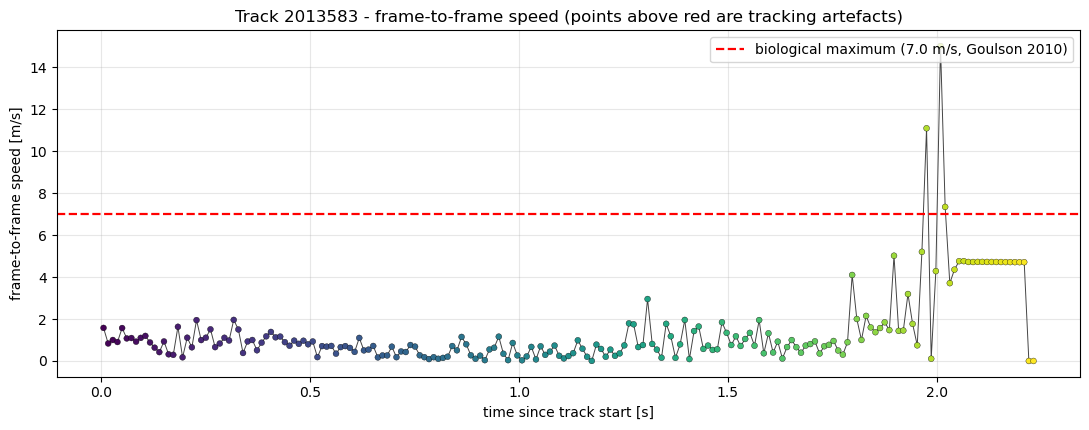

In [19]:
# ── Figure 2: velocity profile ──
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(mid_t, speeds, "-", color="#444", linewidth=0.7)
ax.scatter(mid_t, speeds, c=mid_t, cmap="viridis", s=18,
           edgecolor="black", linewidth=0.25, zorder=3)
ax.axhline(MAX_BIO_VELOCITY, color="red", linestyle="--", linewidth=1.6,
           label=f"biological maximum ({MAX_BIO_VELOCITY} m/s, Goulson 2010)")
ax.set_xlabel("time since track start [s]")
ax.set_ylabel("frame-to-frame speed [m/s]")
ax.set_title(f"Track {UID} - frame-to-frame speed (points above red are tracking artefacts)")
ax.legend(loc="upper right"); ax.grid(alpha=0.3)
plt.tight_layout()

if SAVE_FIGS:
    out = FIG_OUT_DIR / "jitter_velocity_profile.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"saved {out.resolve()}")
plt.show()


## Figure 3 — Before vs after spike-heal + smooth

Applies the same cleaning rule as `heal_and_smooth_track` in
`multi_day_pipeline_v3.ipynb`: nullify spike frames, linearly
interpolate the gaps, then take a centred 5-frame rolling-mean.

saved /Users/jaspe/Projects/Claude/Overleaf/Images/jitter_before_after_preprocessing.png


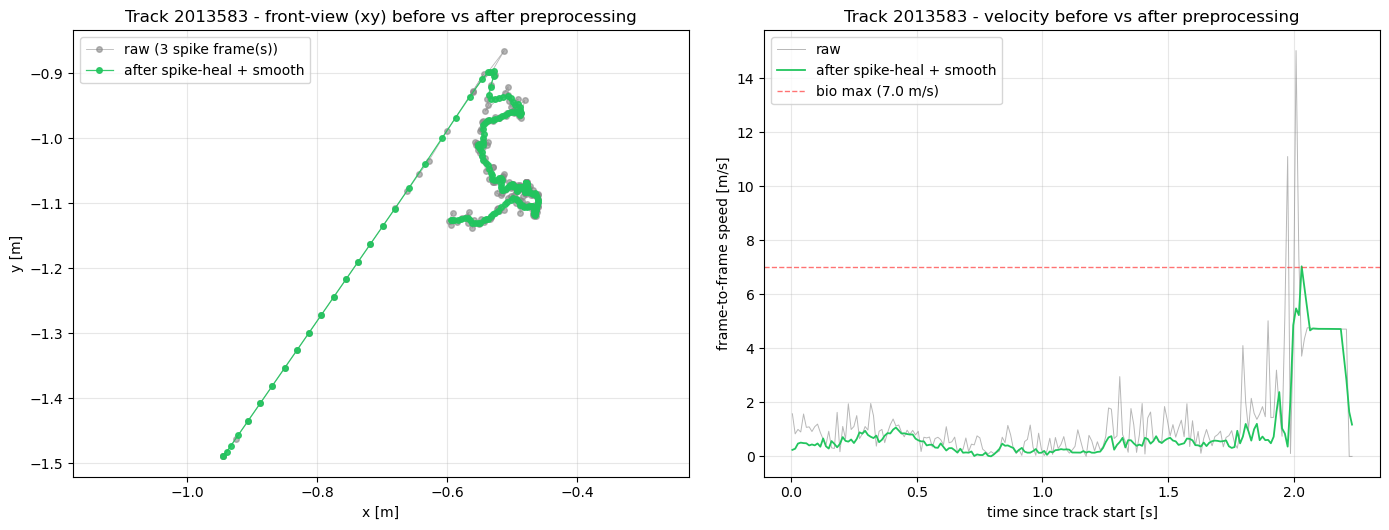


Summary:
  Raw     : peak 15.02 m/s
  Cleaned : peak 7.04 m/s


In [22]:
# ── Figure 3: before / after spike-heal + smooth ──
coords = pd.DataFrame({"x": x, "y": y, "z": z})
coords.loc[spike_mask, :] = np.nan
coords = coords.interpolate(method="linear", limit_direction="both")
smoothed = coords.rolling(window=SMOOTH_WINDOW, center=True, min_periods=1).mean()
xx, yy, zz   = smoothed["x"].values, smoothed["y"].values, smoothed["z"].values
speeds_clean = np.linalg.norm(np.diff(smoothed.values, axis=0), axis=1) / dt

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))

ax = axes[0]
ax.plot(x,  y,  "-o", color="#888", markersize=4, linewidth=0.6, alpha=0.6,
        label=f"raw ({n_spikes} spike frame(s))")
ax.plot(xx, yy, "-o", color="#22C55E", markersize=4, linewidth=0.9, alpha=0.9,
        label="after spike-heal + smooth")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title(f"Track {UID} - front-view (xy) before vs after preprocessing")
ax.legend(); ax.set_aspect("equal", adjustable="datalim"); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(mid_t, speeds,       "-", color="#888", linewidth=0.7, alpha=0.6, label="raw")
ax.plot(mid_t, speeds_clean, "-", color="#22C55E", linewidth=1.3, label="after spike-heal + smooth")
ax.axhline(MAX_BIO_VELOCITY, color="red", linestyle="--", linewidth=1.0, alpha=0.55,
           label=f"bio max ({MAX_BIO_VELOCITY} m/s)")
ax.set_xlabel("time since track start [s]"); ax.set_ylabel("frame-to-frame speed [m/s]")
ax.set_title(f"Track {UID} - velocity before vs after preprocessing")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()

if SAVE_FIGS:
    out = FIG_OUT_DIR / "jitter_before_after_preprocessing.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"saved {out.resolve()}")
plt.show()

print(f"\nSummary:")
print(f"  Raw     : peak {speeds.max():.2f} m/s")
print(f"  Cleaned : peak {speeds_clean.max():.2f} m/s")
